# nb21 - Containment upper-bound: is sigma_eff = 0.03 reachable?

The error analysis (nb16) showed the min-bias floor is **containment** (corr(|residual|,|1-C|)=0.977), a cell-**selection** problem, not model capacity. Before chasing 0.03 with better architectures, this notebook asks the training-free question: **does the information for 0.03 exist at any window / timing selection?**

Method: build once keeping *all* cells per cluster (sorted by distance to the seed), then in memory sweep the spatial window N and an in-time cut (|dt to seed| < tau, dt from `cell_times_front`). For each selection we calibrate the cell-sum to true energy and measure sigma_eff. The calibrated sum is a simple estimator that the transformer already beats, so its sigma_eff is an optimistic *reference* for that input: if even the best window+timing sum cannot approach 0.03, no head on that input will.

In [1]:
import sys, pathlib, os
import numpy as np, pandas as pd, uproot, awkward as ak, matplotlib.pyplot as plt
REPO = pathlib.Path(os.environ['REPO_DIR']) if os.environ.get('REPO_DIR') else (
    pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd())
sys.path.insert(0, str(REPO / 'scripts'))
from run_experiments import derive_geom, split, resolution, CELL_KEYS, EPS
FIG = REPO / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
FILES = sorted((REPO / 'data' / 'minimum_bias').glob('matched_*.root'))
print(len(FILES), 'minbias files')

94 minbias files


## Load once, keep all cells per cluster (sorted by distance to seed)
For each cluster (vz<100): store cell energies, distance-to-seed `rdr`, and seed-relative front time `dt` (NaN where the cell time is the sentinel). Sorted by `rdr` so a window of size N is just the first N entries.

In [2]:
TK = CELL_KEYS + ['cell_times_front']
AUX = ['sig_flux_prod_vertex_z', 'sig_flux_eTot']
def load_all(files):
    E, R, T, Et = [], [], [], []
    for path in files:
        with uproot.open(path) as f:
            a = f['clusters_matched'].arrays(TK + AUX, library='ak')
        vz = ak.to_numpy(a['sig_flux_prod_vertex_z']).astype(float)
        for i in np.flatnonzero(vz < 100.0):
            cc = {k: np.asarray(ak.to_numpy(a[k][i])).astype(float) for k in TK}
            e = cc['energy']
            if len(e) == 0: continue
            seed = int(np.argmax(e))
            rdr = np.hypot(cc['cell_x'] - cc['cell_x'][seed], cc['cell_y'] - cc['cell_y'][seed])
            tf = cc['cell_times_front']; vfr = np.abs(tf) < 1e6
            t0 = tf[seed] if vfr[seed] else (np.median(tf[vfr]) if vfr.any() else 0.0)
            dt = np.where(vfr, tf - t0, np.nan)
            o = np.argsort(rdr)
            E.append(e[o]); R.append(rdr[o]); T.append(dt[o]); Et.append(float(a['sig_flux_eTot'][i]))
    return E, R, T, np.array(Et)
E, R, T, Et = load_all(FILES)
print('clusters', len(Et), '| cells/cluster median', int(np.median([len(e) for e in E])),
      '| max', max(len(e) for e in E))

clusters 89797 | cells/cluster median 81 | max 528


## Calibrated-sum sigma_eff for an arbitrary per-cluster cell mask
`sig_eff_of(masks)` sums the masked cell energies per cluster, fits `log(sum)->log(Etrue)` on the train split, and returns the test sigma_eff plus the containment spread (IQR/1.349 of sum/Etrue, normalised).

In [3]:
keep = np.flatnonzero((Et >= 1.0) & (Et <= 100.0))
tr, va, te = (keep[s] for s in split(len(keep)))
def sig_eff_of(sums):
    s = np.asarray(sums); good = s > 0
    la, lb = np.polyfit(np.log(s[tr] + EPS), np.log(Et[tr]), 1)
    pred = np.exp(la * np.log(s[te] + EPS) + lb)
    C = s / np.median(s[Et > 0] / Et[Et > 0] + EPS) / Et
    cspread = (np.percentile(C[te], 75) - np.percentile(C[te], 25)) / 1.349
    return resolution(pred, Et[te])['sigma_eff'], float(cspread)

## 1) Spatial window scan (all cells)
Grow the window N; more cells recover leaked signal but also admit more pileup.

In [4]:
WINDOWS = [9, 15, 25, 40, 60, 81, 120, 200]
rows = []
for N in WINDOWS:
    sums = np.array([e[:N].sum() for e in E])
    s, cs = sig_eff_of(sums)
    avg_cells = np.mean([min(N, len(e)) for e in E])
    rows.append((N, s, cs, avg_cells)); print(f'N={N:4d} cells~{avg_cells:5.1f}  sum sigma_eff={s:.4f}  C-spread={cs:.3f}')
WS = pd.DataFrame(rows, columns=['N', 'sigma_eff', 'C_spread', 'avg_cells'])

N=   9 cells~  9.0  sum sigma_eff=0.1096  C-spread=0.137
N=  15 cells~ 14.7  sum sigma_eff=0.1400  C-spread=0.189


N=  25 cells~ 24.1  sum sigma_eff=0.1837  C-spread=0.267


N=  40 cells~ 37.0  sum sigma_eff=0.2322  C-spread=0.356
N=  60 cells~ 50.3  sum sigma_eff=0.2673  C-spread=0.449


N=  81 cells~ 63.1  sum sigma_eff=0.2938  C-spread=0.540


N= 120 cells~ 79.2  sum sigma_eff=0.3166  C-spread=0.667
N= 200 cells~101.2  sum sigma_eff=0.3347  C-spread=0.793


## 2) In-time cut at a large window (data-driven pileup rejection)
At the widest window, keep cells whose seed-relative time |dt|<tau (timed cells only) plus all untimed cells (they carry no timing info, so cannot be time-rejected). Scan tau to see how far perfect-ish in-time selection pushes the floor. `tau=inf` reproduces the all-cell sum.

In [5]:
NBIG = 120
TAUS = [np.inf, 3.0, 2.0, 1.0, 0.5]
rows = []
for tau in TAUS:
    sums = []
    for e, dt in zip(E, T):
        m = np.ones(min(NBIG, len(e)), dtype=bool)
        d = dt[:NBIG][:len(m)]
        timed = ~np.isnan(d)
        m = m & (~timed | (np.abs(np.nan_to_num(d)) <= tau))
        sums.append(e[:NBIG][:len(m)][m].sum())
    s, cs = sig_eff_of(sums)
    rows.append((tau, s, cs)); print(f'tau={tau!s:5}  in-time sum sigma_eff={s:.4f}  C-spread={cs:.3f}')
TS = pd.DataFrame(rows, columns=['tau', 'sigma_eff', 'C_spread'])

tau=inf    in-time sum sigma_eff=0.3166  C-spread=0.667


tau=3.0    in-time sum sigma_eff=0.3156  C-spread=0.664


tau=2.0    in-time sum sigma_eff=0.3149  C-spread=0.662


tau=1.0    in-time sum sigma_eff=0.3138  C-spread=0.667


tau=0.5    in-time sum sigma_eff=0.3111  C-spread=0.662


## Plot + verdict

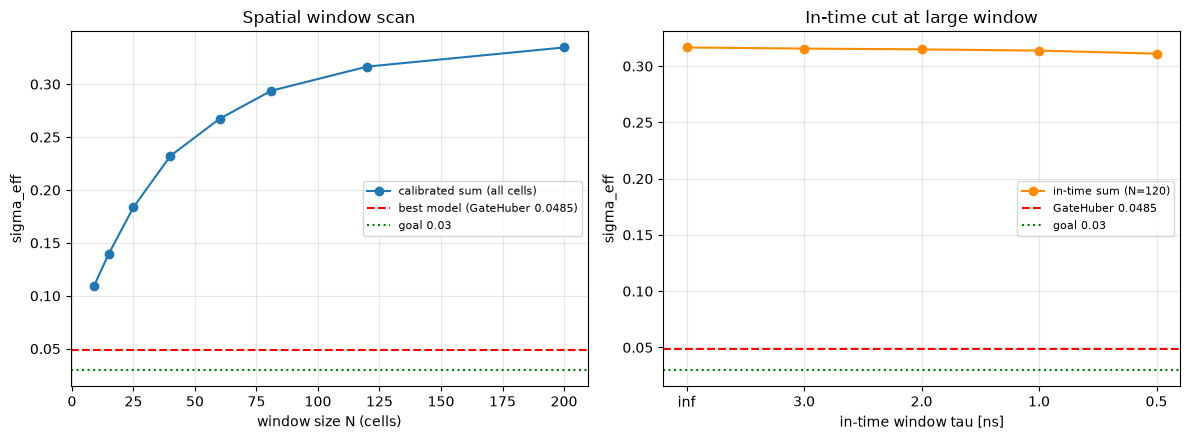

best sum sigma_eff (any window): 0.1096
best in-time sum sigma_eff: 0.3111
VERDICT: 0.03 needs a calibrated-sum reference at/below ~0.03-0.04 to be plausible for a head.


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(WS['N'], WS['sigma_eff'], 'o-', label='calibrated sum (all cells)')
ax[0].axhline(0.0485, ls='--', color='r', label='best model (GateHuber 0.0485)')
ax[0].axhline(0.03, ls=':', color='g', label='goal 0.03')
ax[0].set_xlabel('window size N (cells)'); ax[0].set_ylabel('sigma_eff'); ax[0].set_title('Spatial window scan')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
tl = [str(t) for t in TS['tau']]
ax[1].plot(range(len(TS)), TS['sigma_eff'], 'o-', color='darkorange', label=f'in-time sum (N={NBIG})')
ax[1].axhline(0.0485, ls='--', color='r', label='GateHuber 0.0485')
ax[1].axhline(0.03, ls=':', color='g', label='goal 0.03')
ax[1].set_xticks(range(len(TS))); ax[1].set_xticklabels(tl); ax[1].set_xlabel('in-time window tau [ns]')
ax[1].set_ylabel('sigma_eff'); ax[1].set_title('In-time cut at large window'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG / 'fig6_oracle_containment.png', dpi=130); plt.show()
print('best sum sigma_eff (any window):', round(WS['sigma_eff'].min(), 4))
print('best in-time sum sigma_eff:', round(TS['sigma_eff'].min(), 4))
print('VERDICT: 0.03 needs a calibrated-sum reference at/below ~0.03-0.04 to be plausible for a head.')